# OFAC SDN Watchlist — Advanced Data Profiling & Analytics

**Dataset:** OFAC Specially Designated Nationals (SDN) List  
**Source:** https://sanctionslist.ofac.treas.gov  

## Objective
This notebook performs advanced profiling and analysis of the OFAC SDN sanctions watchlist —
mirroring real-world compliance data analyst workflows in AML/sanctions screening.

## Sections
1. Data Loading & Preprocessing
2. Data Cleaning — Raw → Clean Dataset
3. Advanced Data Quality Assessment
4. Entity & Program Profiling
5. NLP Analysis — Name Patterns & Alias Detection
6. Time Series — Sanctions Trend Analysis
7. Network Graph — Entity Relationship Mapping


## 0. Install & Import Dependencies

In [1]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib seaborn networkx spacy plotly fuzzywuzzy python-Levenshtein
# !python -m spacy download en_core_web_sm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import re
import warnings
from collections import Counter
from fuzzywuzzy import fuzz
from itertools import combinations

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

print('All libraries loaded.')

All libraries loaded.


## 1. Data Loading & Preprocessing

In [2]:
# --- Load Main SDN List ---
cols = ['ent_num', 'sdn_name', 'sdn_type', 'program', 'title',
        'call_sign', 'vess_type', 'tonnage', 'grt', 'vess_flag',
        'vess_owner', 'remarks']

df = pd.read_csv('../data/sdn.csv', names=cols, encoding='latin-1')

# Strip whitespace
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

# Replace ALL -0- variants with NaN first (with and without whitespace)
df.replace(to_replace=r'^\s*-0-\s*$', value=np.nan, regex=True, inplace=True)

# Then set sdn_type NaN → 'entity'
df['sdn_type'] = df['sdn_type'].fillna('entity')
# Then set sdn_type NaN → 'entity'
df['sdn_type'] = df['sdn_type'].fillna('entity')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

print(df['sdn_type'].value_counts())

Shape: (18710, 12)
Columns: ['ent_num', 'sdn_name', 'sdn_type', 'program', 'title', 'call_sign', 'vess_type', 'tonnage', 'grt', 'vess_flag', 'vess_owner', 'remarks']
sdn_type
entity        9521
individual    7391
vessel        1456
aircraft       342
Name: count, dtype: int64


In [3]:
# --- Parse remarks into structured fields ---
def extract_field(remark, pattern):
    if pd.isna(remark):
        return None
    match = re.search(pattern, remark, re.IGNORECASE)
    return match.group(1).strip() if match else None

df['nationality']  = df['remarks'].apply(lambda x: extract_field(x, r'nationality\s+([A-Za-z\s,]+?)(?:;|\.|$)'))
df['dob']          = df['remarks'].apply(lambda x: extract_field(x, r'DOB\s+([\d\w\s,]+?)(?:;|\.|$)'))
df['pob']          = df['remarks'].apply(lambda x: extract_field(x, r'POB\s+([A-Za-z\s,]+?)(?:;|\.|$)'))
df['passport']     = df['remarks'].apply(lambda x: extract_field(x, r'Passport\s+([A-Z0-9]+?)(?:;|\s|$)'))
df['id_number']    = df['remarks'].apply(lambda x: extract_field(x, r'\bID\b\s+([A-Z0-9]+?)(?:;|\s|$)'))
df['aka_count']    = df['remarks'].apply(lambda x: len(re.findall(r'a\.k\.a\.|aka', x, re.IGNORECASE)) if pd.notna(x) else 0)

# Parse year from DOB
df['dob_year'] = df['dob'].apply(lambda x: re.search(r'(19|20)\d{2}', x).group(0) if pd.notna(x) and re.search(r'(19|20)\d{2}', x) else None)
df['dob_year'] = pd.to_numeric(df['dob_year'], errors='coerce')

# Explode multi-program entries
df['program_list'] = df['program'].str.replace('[', '', regex=False).str.replace(']', ' ', regex=False).str.split()

print('Feature extraction complete.')
df[['sdn_name','sdn_type','nationality','dob_year','aka_count']].head()

Feature extraction complete.


,sdn_name,sdn_type,nationality,dob_year,aka_count
0,AEROCARIBBEAN AIRLINES,entity,NaN,NaN,0
1,"ANGLO-CARIBBEAN CO., LTD.",entity,NaN,NaN,0
2,BANCO NACIONAL DE CUBA,entity,NaN,NaN,1
3,BOUTIQUE LA MAISON,entity,NaN,NaN,0
4,CASA DE CUBA,entity,NaN,NaN,0


## 1.5 Data Cleaning — Raw → Clean Dataset

In [4]:
# ============================================================
# STEP 1: Copy raw df — always preserve original
# ============================================================
df_raw   = df.copy()
df_clean = df.copy()

print(f'Raw shape: {df_raw.shape}')

Raw shape: (18710, 20)


In [5]:
# ============================================================
# STEP 2: Standardise casing
# ============================================================
# sdn_name → Title Case (consistent with how names appear in documents)
df_clean['sdn_name'] = df_clean['sdn_name'].str.title()

# sdn_type → lowercase for consistency
df_clean['sdn_type'] = df_clean['sdn_type'].str.lower().str.strip()

# nationality → Title Case
df_clean['nationality'] = df_clean['nationality'].str.title().str.strip()

# pob → Title Case
df_clean['pob'] = df_clean['pob'].str.title().str.strip()

# Verify
print('=== CASING STANDARDISATION ===')
print(f'sdn_type unique values after cleaning: {df_clean["sdn_type"].dropna().unique()}')
print(f'Sample names (before): {df_raw["sdn_name"].head(3).tolist()}')
print(f'Sample names (after):  {df_clean["sdn_name"].head(3).tolist()}')

=== CASING STANDARDISATION ===
sdn_type unique values after cleaning: <StringArray>
['entity', 'individual', 'vessel', 'aircraft']
Length: 4, dtype: str
Sample names (before): ['AEROCARIBBEAN AIRLINES', 'ANGLO-CARIBBEAN CO., LTD.', 'BANCO NACIONAL DE CUBA']
Sample names (after):  ['Aerocaribbean Airlines', 'Anglo-Caribbean Co., Ltd.', 'Banco Nacional De Cuba']


In [6]:
# ============================================================
# STEP 3: Standardise nationality strings
# ============================================================
# Map known variants to canonical forms
nationality_map = {
    'Iranian'      : 'Iran',
    'Iranian '     : 'Iran',
    'Syrian'       : 'Syria',
    'North Korean' : 'North Korea',
    'Korean'       : 'North Korea',
    'Russian'      : 'Russia',
    'Chinese'      : 'China',
    'Venezuelan'   : 'Venezuela',
    'Cuban'        : 'Cuba',
    'Libyan'       : 'Libya',
    'Iraqi'        : 'Iraq',
    'Sudanese'     : 'Sudan',
    'Belarusian'   : 'Belarus',
    'Burmese'      : 'Myanmar',
}

df_clean['nationality'] = df_clean['nationality'].replace(nationality_map)

# Strip trailing whitespace / punctuation artifacts
df_clean['nationality'] = df_clean['nationality'].str.strip().str.rstrip('.,;')

print('=== NATIONALITY STANDARDISATION ===')
print(f'Unique nationalities before: {df_raw["nationality"].nunique()}')
print(f'Unique nationalities after:  {df_clean["nationality"].nunique()}')
print(f'\nTop 10 nationalities (clean):')
print(df_clean['nationality'].value_counts().head(10))

=== NATIONALITY STANDARDISATION ===
Unique nationalities before: 146
Unique nationalities after:  146

Top 10 nationalities (clean):
nationality
Russia          1693
Iran             604
Mexico           451
Iraq             161
China            152
Belarus          141
Lebanon          136
Syria            134
Korea, North     132
Venezuela         94
Name: count, dtype: int64


In [7]:
# ============================================================
# STEP 4: Remove exact duplicate rows
# ============================================================
before = len(df_clean)
cols_to_check = [c for c in df_clean.columns if c != 'program_list']
df_clean = df_clean.drop_duplicates(subset=cols_to_check)
after = len(df_clean)

print(f'Rows before deduplication: {before:,}')
print(f'Rows after deduplication:  {after:,}')
print(f'Duplicates removed:        {before - after}')

Rows before deduplication: 18,710
Rows after deduplication:  18,710
Duplicates removed:        0


In [8]:
# ============================================================
# STEP 5: Validate & constrain sdn_type values
# ============================================================
valid_types = ['individual', 'entity', 'vessel', 'aircraft']
invalid_mask = ~df_clean['sdn_type'].isin(valid_types) & df_clean['sdn_type'].notna()

print(f'Invalid sdn_type values found: {invalid_mask.sum()}')
if invalid_mask.sum() > 0:
    print(df_clean[invalid_mask][['sdn_name','sdn_type']].head())

# Tag invalid types as 'unknown' for downstream handling
df_clean.loc[invalid_mask, 'sdn_type'] = 'unknown'
print(f'\nsdn_type distribution after cleaning:')
print(df_clean['sdn_type'].value_counts())

Invalid sdn_type values found: 0

sdn_type distribution after cleaning:
sdn_type
entity        9521
individual    7391
vessel        1456
aircraft       342
Name: count, dtype: int64


In [9]:
# ============================================================
# STEP 6: Clean & validate DOB year
# ============================================================
# Flag implausible birth years
implausible = df_clean[(df_clean['dob_year'] < 1900) | (df_clean['dob_year'] > 2015)]
print(f'Implausible DOB years: {len(implausible)}')
if len(implausible) > 0:
    print(implausible[['sdn_name','dob','dob_year']].head())

# Nullify implausible years
df_clean.loc[(df_clean['dob_year'] < 1900) | (df_clean['dob_year'] > 2015), 'dob_year'] = np.nan

print(f'\nDOB year range after cleaning: {df_clean["dob_year"].min():.0f} – {df_clean["dob_year"].max():.0f}')

Implausible DOB years: 0

DOB year range after cleaning: 1921 – 2006


In [10]:
# ============================================================
# STEP 7: Add data quality flag column
# ============================================================
# Flag records that are missing critical identity fields
# Useful for downstream risk scoring — incomplete records = higher screening risk

def compute_dq_flag(row):
    issues = []
    if row['sdn_type'] == 'individual':
        if pd.isna(row['dob']):         issues.append('MISSING_DOB')
        if pd.isna(row['nationality']): issues.append('MISSING_NATIONALITY')
        if pd.isna(row['passport']):    issues.append('MISSING_PASSPORT')
    if row['sdn_type'] == 'vessel':
        if pd.isna(row['vess_flag']):   issues.append('MISSING_FLAG')
        if pd.isna(row['vess_type']):   issues.append('MISSING_VESSEL_TYPE')
    if pd.isna(row['program']):
        issues.append('MISSING_PROGRAM')
    return '|'.join(issues) if issues else 'CLEAN'

df_clean['dq_flag'] = df_clean.apply(compute_dq_flag, axis=1)

flag_summary = df_clean['dq_flag'].value_counts().head(10)
print('=== DATA QUALITY FLAGS ===')
print(flag_summary)
print(f'\nClean records: {(df_clean["dq_flag"] == "CLEAN").sum():,} ({(df_clean["dq_flag"] == "CLEAN").mean()*100:.1f}%)')
print(f'Flagged records: {(df_clean["dq_flag"] != "CLEAN").sum():,} ({(df_clean["dq_flag"] != "CLEAN").mean()*100:.1f}%)')

=== DATA QUALITY FLAGS ===
dq_flag
CLEAN                                               12715
MISSING_PASSPORT                                     3803
MISSING_NATIONALITY|MISSING_PASSPORT                 1519
MISSING_NATIONALITY                                   421
MISSING_VESSEL_TYPE                                    95
MISSING_DOB|MISSING_NATIONALITY|MISSING_PASSPORT       62
MISSING_DOB|MISSING_PASSPORT                           31
MISSING_FLAG                                           30
MISSING_DOB|MISSING_NATIONALITY                        18
MISSING_DOB                                             8
Name: count, dtype: int64

Clean records: 12,715 (68.0%)
Flagged records: 5,995 (32.0%)


In [11]:
# ============================================================
# STEP 8: Before vs After Cleaning Summary + Export
# ============================================================
print('=' * 55)
print('       CLEANING SUMMARY: RAW vs CLEAN')
print('=' * 55)
print(f'{"Metric":<35} {"Raw":>8} {"Clean":>8}')
print('-' * 55)
print(f'{"Total rows":<35} {len(df_raw):>8,} {len(df_clean):>8,}')
hash_cols = [c for c in df_raw.columns if c != 'program_list']
print(f'{"Duplicate rows":<35} {df_raw.duplicated(subset=hash_cols).sum():>8} {df_clean.duplicated(subset=[c for c in df_clean.columns if c != "program_list"]).sum():>8}')
print(f'{"Unique nationalities":<35} {df_raw["nationality"].nunique():>8} {df_clean["nationality"].nunique():>8}')
print(f'{"Invalid sdn_type values":<35} {(~df_raw["sdn_type"].str.lower().isin(valid_types + [None])).sum():>8} {(df_clean["sdn_type"] == "unknown").sum():>8}')
print(f'{"Implausible DOB years":<35} {len(implausible):>8} {0:>8}')
print(f'{"Records with DQ flags":<35} {"N/A":>8} {(df_clean["dq_flag"] != "CLEAN").sum():>8}')
print('=' * 55)

# Export clean dataset
df_clean.to_csv('../outputs/sdn_clean.csv', index=False)
print('\n Clean dataset exported → outputs/sdn_clean.csv')
print('   All downstream sections use df_clean.')

       CLEANING SUMMARY: RAW vs CLEAN
Metric                                   Raw    Clean
-------------------------------------------------------
Total rows                            18,710   18,710
Duplicate rows                             0        0
Unique nationalities                     146      146
Invalid sdn_type values                    0        0
Implausible DOB years                      0        0
Records with DQ flags                    N/A     5995

 Clean dataset exported → outputs/sdn_clean.csv
   All downstream sections use df_clean.


## 2. Advanced Data Quality Assessment

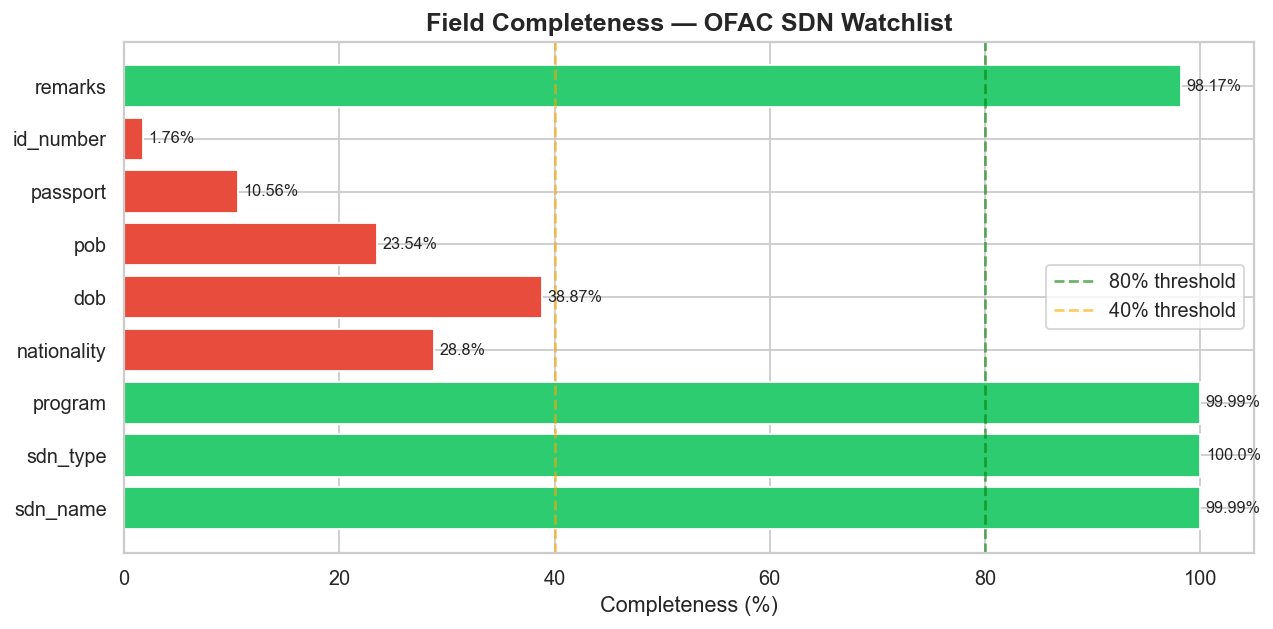

      Field  Non-Null Count  Null Count  Completeness %
   sdn_name           18709           1           99.99
   sdn_type           18710           0          100.00
    program           18709           1           99.99
nationality            5389       13321           28.80
        dob            7272       11438           38.87
        pob            4404       14306           23.54
   passport            1976       16734           10.56
  id_number             330       18380            1.76
    remarks           18367         343           98.17


In [12]:
# --- 2.1 Completeness Matrix ---
key_fields = ['sdn_name','sdn_type','program','nationality','dob','pob','passport','id_number','remarks']
completeness = pd.DataFrame({
    'Field': key_fields,
    'Non-Null Count': [df[f].notna().sum() for f in key_fields],
    'Null Count':     [df[f].isna().sum()  for f in key_fields],
    'Completeness %': [(df[f].notna().sum() / len(df) * 100).round(2) for f in key_fields]
})

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(completeness['Field'], completeness['Completeness %'],
               color=['#2ecc71' if x >= 80 else '#e67e22' if x >= 40 else '#e74c3c'
                      for x in completeness['Completeness %']])
ax.axvline(80, color='green', linestyle='--', alpha=0.6, label='80% threshold')
ax.axvline(40, color='orange', linestyle='--', alpha=0.6, label='40% threshold')
ax.set_xlabel('Completeness (%)')
ax.set_title('Field Completeness — OFAC SDN Watchlist', fontsize=14, fontweight='bold')
ax.legend()
for bar, val in zip(bars, completeness['Completeness %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/completeness_matrix.png', dpi=150)
plt.show()

print(completeness.to_string(index=False))

In [13]:
# --- 2.2 Duplicate & Consistency Analysis ---
print('=== DUPLICATE ANALYSIS ===')
hash_cols = [c for c in df.columns if c != 'program_list']
print(f'Exact duplicate rows:           {df.duplicated(subset=hash_cols).sum()}')
print(f'Duplicate entity numbers:       {df["ent_num"].duplicated().sum()}')
print(f'Duplicate SDN names:            {df["sdn_name"].duplicated().sum()}')
print(f'Same name, different ent_num:   {df[df.duplicated(subset=["sdn_name"], keep=False)]["ent_num"].nunique()}')

print('\n=== FORMATTING CONSISTENCY ===')
# Check for mixed case
mixed_case = df['sdn_name'].dropna().apply(lambda x: not (x.isupper() or x.islower() or x.istitle()))
print(f'Names with mixed casing:        {mixed_case.sum()} ({mixed_case.mean()*100:.1f}%)')

# Check sdn_type values
print(f'\nSDN Type unique values: {df["sdn_type"].unique()}')

# Check program format consistency
no_bracket = df['program'].dropna().apply(lambda x: '[' not in x)
print(f'Programs missing bracket format: {no_bracket.sum()}')

=== DUPLICATE ANALYSIS ===
Exact duplicate rows:           0
Duplicate entity numbers:       0
Duplicate SDN names:            34
Same name, different ent_num:   65

=== FORMATTING CONSISTENCY ===
Names with mixed casing:        7382 (39.5%)

SDN Type unique values: <StringArray>
['entity', 'individual', 'vessel', 'aircraft']
Length: 4, dtype: str
Programs missing bracket format: 16036


In [14]:
# --- 2.3 Cross-field Consistency Checks ---
print('=== CROSS-FIELD CONSISTENCY CHECKS ===')

# Vessels should have vessel-specific fields populated
vessels = df[df['sdn_type'] == 'vessel']
print(f'\nVessels total: {len(vessels)}')
print(f'  → Missing vessel type:  {vessels["vess_type"].isna().sum()} ({vessels["vess_type"].isna().mean()*100:.1f}%)')
print(f'  → Missing vessel flag:  {vessels["vess_flag"].isna().sum()} ({vessels["vess_flag"].isna().mean()*100:.1f}%)')
print(f'  → Missing vessel owner: {vessels["vess_owner"].isna().sum()} ({vessels["vess_owner"].isna().mean()*100:.1f}%)')

# Individuals should have DOB/nationality
individuals = df[df['sdn_type'] == 'individual']
print(f'\nIndividuals total: {len(individuals)}')
print(f'  → Missing DOB:         {individuals["dob"].isna().sum()} ({individuals["dob"].isna().mean()*100:.1f}%)')
print(f'  → Missing nationality: {individuals["nationality"].isna().sum()} ({individuals["nationality"].isna().mean()*100:.1f}%)')
print(f'  → Missing passport:    {individuals["passport"].isna().sum()} ({individuals["passport"].isna().mean()*100:.1f}%)')

print('\n  High null rates in identity fields = elevated false-negative risk in screening systems.')

=== CROSS-FIELD CONSISTENCY CHECKS ===

Vessels total: 1456
  → Missing vessel type:  102 (7.0%)
  → Missing vessel flag:  37 (2.5%)
  → Missing vessel owner: 1450 (99.6%)

Individuals total: 7391
  → Missing DOB:         119 (1.6%)
  → Missing nationality: 2020 (27.3%)
  → Missing passport:    5415 (73.3%)

  High null rates in identity fields = elevated false-negative risk in screening systems.


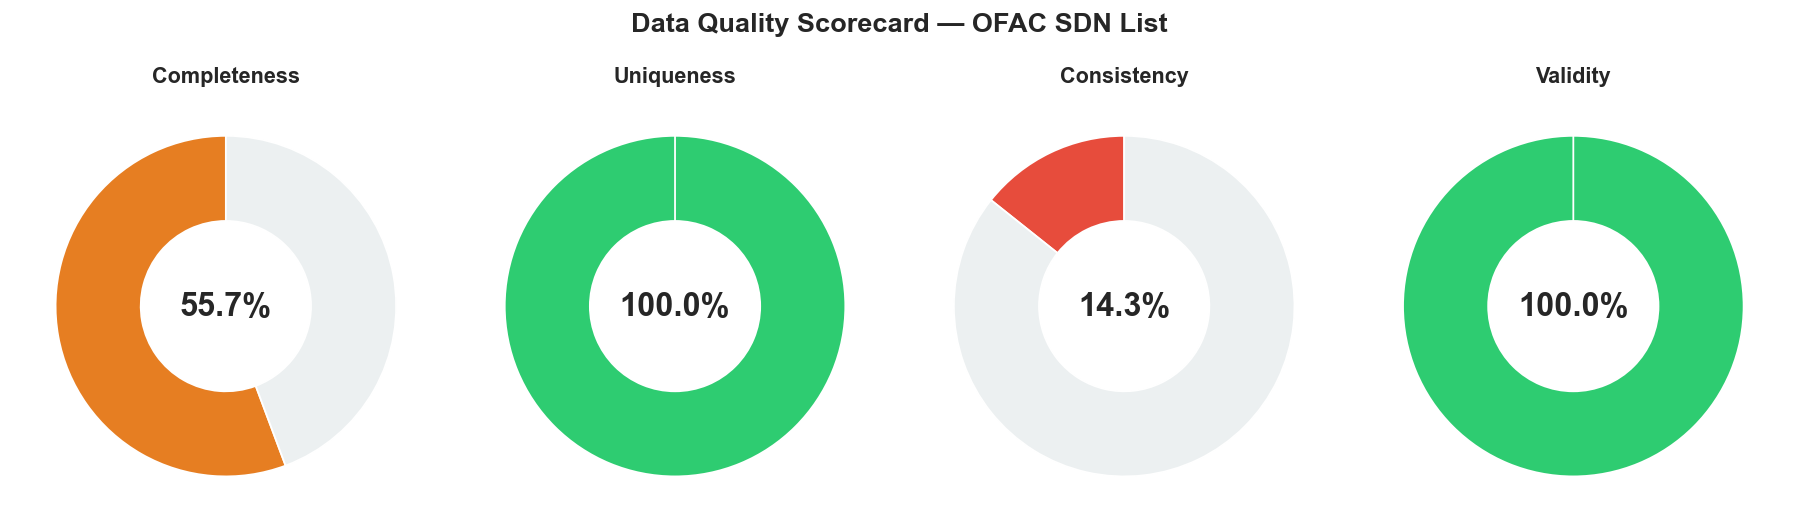

In [15]:
# --- 2.4 Data Quality Scorecard ---
dq_scores = {
    'Completeness':  round(completeness['Completeness %'].mean(), 1),
    'Uniqueness':    round((1 - df.duplicated(subset=[c for c in df.columns if c != 'program_list']).sum() / len(df)) * 100, 1),    'Consistency':   round((1 - no_bracket.mean()) * 100, 1),
    'Validity':      round(df['sdn_type'].isin(['individual','entity','vessel','aircraft']).mean() * 100, 1)
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
colors = ['#2ecc71' if v >= 80 else '#e67e22' if v >= 50 else '#e74c3c' for v in dq_scores.values()]

for ax, (dim, score), color in zip(axes, dq_scores.items(), colors):
    ax.pie([score, 100-score], colors=[color, '#ecf0f1'], startangle=90,
           wedgeprops={'width': 0.5})
    ax.text(0, 0, f'{score}%', ha='center', va='center', fontsize=18, fontweight='bold')
    ax.set_title(dim, fontsize=12, fontweight='bold')

fig.suptitle('Data Quality Scorecard — OFAC SDN List', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/dq_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Entity & Program Profiling

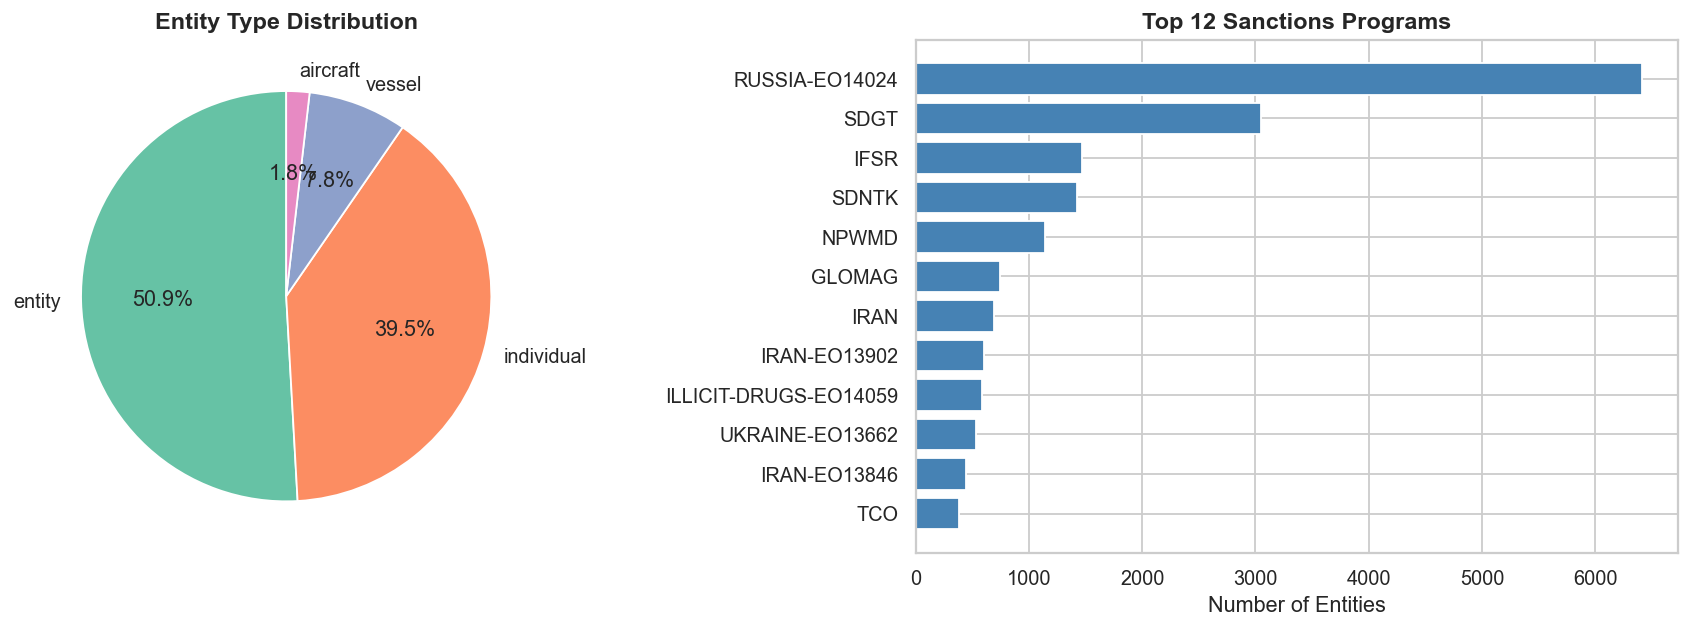

In [16]:
# --- 3.1 Entity Type & Top Programs ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entity types
entity_counts = df['sdn_type'].value_counts()
axes[0].pie(entity_counts, labels=entity_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(entity_counts)), startangle=90)
axes[0].set_title('Entity Type Distribution', fontsize=13, fontweight='bold')

# Top programs
all_programs = df['program_list'].explode().dropna()
top_programs = all_programs.value_counts().head(12)
axes[1].barh(top_programs.index[::-1], top_programs.values[::-1], color='steelblue')
axes[1].set_title('Top 12 Sanctions Programs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Entities')

plt.tight_layout()
plt.savefig('../outputs/entity_program_profile.png', dpi=150)
plt.show()

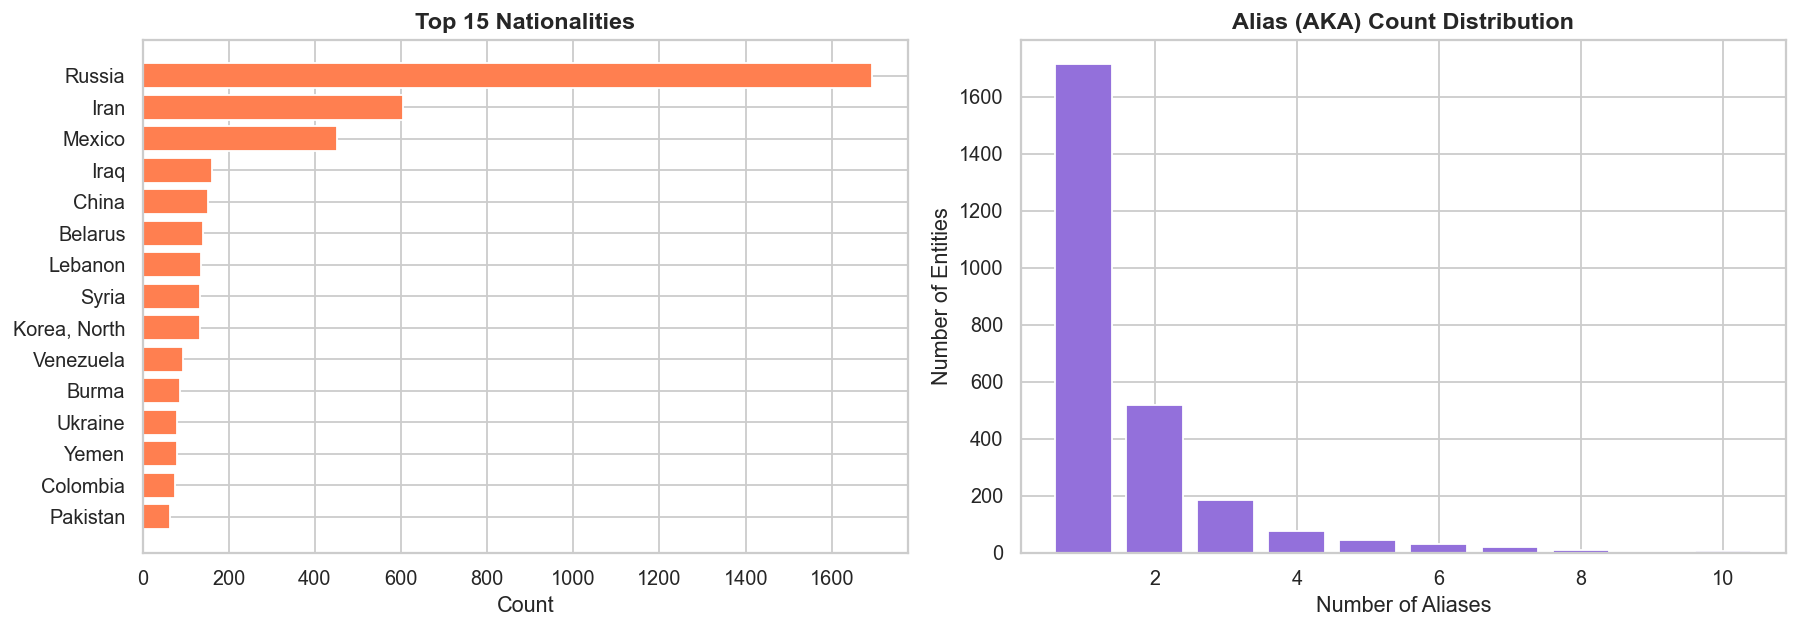

Entities with at least 1 alias: 2601 (13.9%)
Max aliases on one entity: 16


In [17]:
# --- 3.2 Top Nationalities & Alias Density ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top nationalities
top_nat = df['nationality'].value_counts().head(15)
axes[0].barh(top_nat.index[::-1], top_nat.values[::-1], color='coral')
axes[0].set_title('Top 15 Nationalities', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')

# Alias (AKA) count distribution
aka_dist = df[df['aka_count'] > 0]['aka_count'].value_counts().sort_index().head(10)
axes[1].bar(aka_dist.index, aka_dist.values, color='mediumpurple')
axes[1].set_title('Alias (AKA) Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Aliases')
axes[1].set_ylabel('Number of Entities')

plt.tight_layout()
plt.savefig('../outputs/nationality_alias_profile.png', dpi=150)
plt.show()

print(f'Entities with at least 1 alias: {(df["aka_count"] > 0).sum()} ({(df["aka_count"] > 0).mean()*100:.1f}%)')
print(f'Max aliases on one entity: {df["aka_count"].max()}')

## 4. NLP Analysis — Name Patterns & Alias Detection

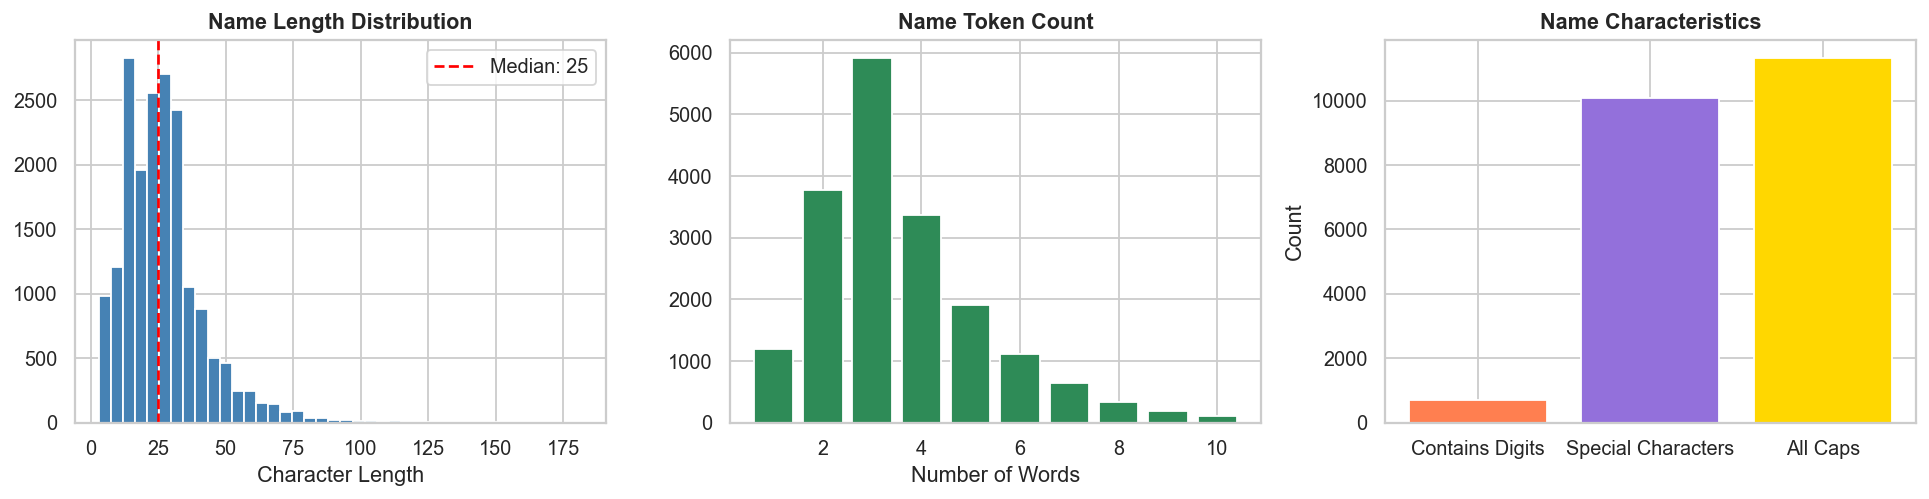

In [18]:
# --- 4.1 Name Length & Token Analysis ---
df['name_length']    = df['sdn_name'].dropna().apply(len)
df['name_tokens']    = df['sdn_name'].dropna().apply(lambda x: len(x.split()))
df['has_numeric']    = df['sdn_name'].dropna().apply(lambda x: bool(re.search(r'\d', x)))
df['has_special']    = df['sdn_name'].dropna().apply(lambda x: bool(re.search(r'[^\w\s]', x)))
df['is_all_caps']    = df['sdn_name'].dropna().apply(lambda x: x.isupper())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Name length distribution
axes[0].hist(df['name_length'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Name Length Distribution', fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].axvline(df['name_length'].median(), color='red', linestyle='--', label=f'Median: {df["name_length"].median():.0f}')
axes[0].legend()

# Token count
token_dist = df['name_tokens'].value_counts().sort_index().head(10)
axes[1].bar(token_dist.index, token_dist.values, color='seagreen')
axes[1].set_title('Name Token Count', fontweight='bold')
axes[1].set_xlabel('Number of Words')

# Name characteristics
characteristics = {
    'Contains Digits': df['has_numeric'].sum(),
    'Special Characters': df['has_special'].sum(),
    'All Caps': df['is_all_caps'].sum()
}
axes[2].bar(characteristics.keys(), characteristics.values(), color=['coral','mediumpurple','gold'])
axes[2].set_title('Name Characteristics', fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/name_nlp_analysis.png', dpi=150)
plt.show()

Top corporate keywords in sanctioned entity names:
  Company             : 2713
  Ltd                 : 818
  Co                  : 723
  Trading             : 452
  Llc                 : 373
  Group               : 263
  International       : 248
  Bank                : 223
  Inc                 : 116
  Services            : 116
  General             : 110
  Enterprise          : 104
  Holdings            : 51
  Corp                : 50
  Export              : 46
  Import              : 45
  Finance             : 24


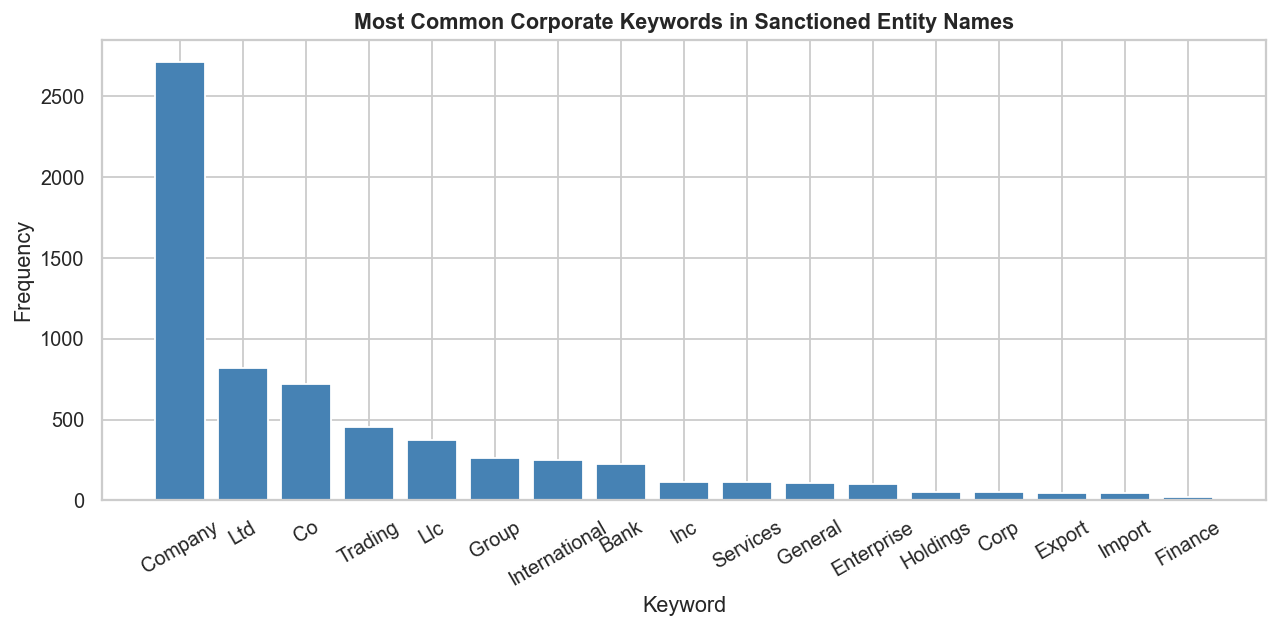

Top corporate keywords in sanctioned entity names:
  Company             : 2713
  Ltd                 : 818
  Co                  : 723
  Trading             : 452
  Llc                 : 373
  Group               : 263
  International       : 248
  Bank                : 223
  Inc                 : 116
  Services            : 116
  General             : 110
  Enterprise          : 104
  Holdings            : 51
  Corp                : 50
  Export              : 46
  Import              : 45
  Finance             : 24


In [29]:
import re

# --- 4.2 Common Name Prefixes / Titles (Entity Naming Conventions) ---
def extract_prefix(name):
    if pd.isna(name): return None
    tokens = name.strip().split()
    return tokens[0].upper() if tokens else None

# For entities only — look at company-type keywords
entity_names = df_clean[df_clean['sdn_type'] == 'entity']['sdn_name'].dropna()

# Strip punctuation before splitting so 'Co.,' matches 'Co'
cleaned_entity_text = re.sub(r'[^\w\s]', ' ', ' '.join(entity_names))
entity_words = cleaned_entity_text.split()

corporate_keywords = ['Company', 'Co', 'Ltd', 'Llc', 'Corp', 'Inc', 'Group',
                      'Trading', 'Import', 'Export', 'International', 'General',
                      'Bank', 'Finance', 'Holdings', 'Enterprise', 'Services']

keyword_counts = {k: entity_words.count(k) for k in corporate_keywords}
keyword_counts = dict(sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True))

print('Top corporate keywords in sanctioned entity names:')
for k, v in keyword_counts.items():
    print(f'  {k:20s}: {v}')
plt.figure(figsize=(10, 5))
plt.bar(keyword_counts.keys(), keyword_counts.values(), color='steelblue')
plt.title('Most Common Corporate Keywords in Sanctioned Entity Names', fontweight='bold')
plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../outputs/entity_naming_conventions.png', dpi=150)
plt.show()

print('Top corporate keywords in sanctioned entity names:')
for k, v in keyword_counts.items():
    print(f'  {k:20s}: {v}')


In [31]:
# --- 4.3 Fuzzy Name Matching — Near-Duplicate Detection ---

def fuzzy_screen(query_name, watchlist, threshold=85):
    """Screen a name against watchlist using fuzzy matching."""
    matches = []
    for name in watchlist:
        score = fuzz.token_sort_ratio(query_name.upper(), str(name).upper())
        if score >= threshold:
            matches.append({'matched_name': name, 'score': score})
    return sorted(matches, key=lambda x: x['score'], reverse=True)

# Use FULL watchlist, not just 3000
watchlist_sample = df_clean['sdn_name'].dropna().tolist()
print(f'Watchlist size: {len(watchlist_sample)}')

# Lower threshold to 70 to see if anything matches at all
test_queries = ['Iran Air', 'Al Qaeda', 'Bank Melli', 'Islamic Revolutionary']

print('=== FUZZY SCREENING RESULTS (threshold=70) ===\n')
for query in test_queries:
    results = fuzzy_screen(query, watchlist_sample, threshold=70)
    print(f'Query: "{query}"')
    if results:
        for r in results[:3]:
            print(f'  → Match: {r["matched_name"]} | Score: {r["score"]}')
    else:
        print('  → No matches above threshold')
    print()

Watchlist size: 18709
=== FUZZY SCREENING RESULTS (threshold=70) ===

Query: "Iran Air"
  → Match: Iran Air | Score: 100
  → Match: Iran Charak | Score: 74
  → Match: Dianat, Amir | Score: 74

Query: "Al Qaeda"
  → No matches above threshold

Query: "Bank Melli"
  → Match: Bank Mellat | Score: 86
  → Match: Melli Bank Plc | Score: 83
  → Match: Bank Melli Iran | Score: 80

Query: "Islamic Revolutionary"
  → Match: Islamic Revolutionary Guard Corps | Score: 78



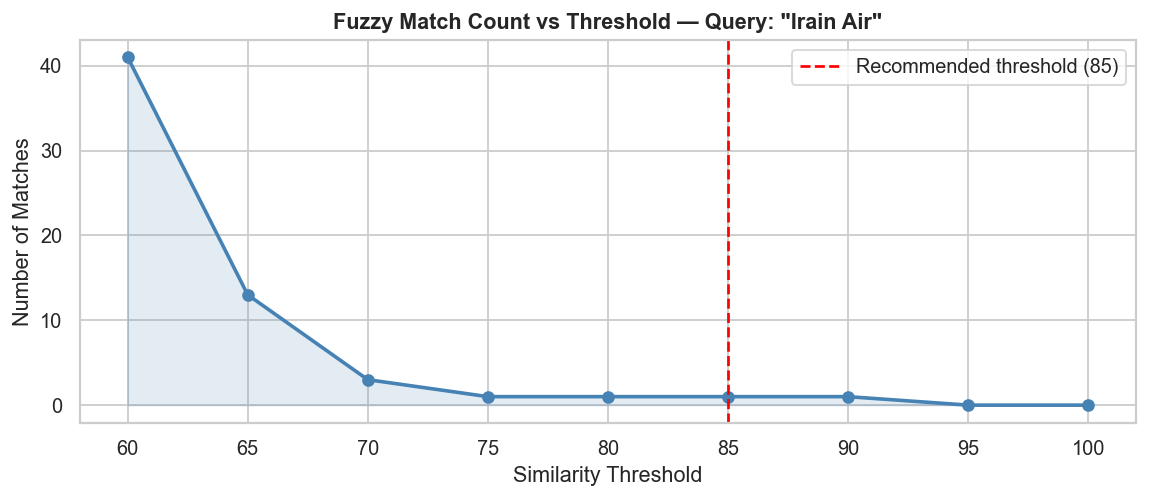


  Lower thresholds = higher recall but more false positives.
  Higher thresholds = fewer alerts but risk missing near-matches (false negatives).
  In AML screening, false negatives carry greater regulatory risk.


In [38]:
# --- 4.4 Threshold Sensitivity Analysis ---
# How many matches do we get at different fuzzy thresholds? (Precision vs Recall tradeoff)
query = 'Irain Air'
thresholds = range(60, 101, 5)
match_counts = []

for t in thresholds:
    results = fuzzy_screen(query, watchlist_sample, threshold=t)
    match_counts.append(len(results))

plt.figure(figsize=(9, 4))
plt.plot(list(thresholds), match_counts, marker='o', color='steelblue', linewidth=2)
plt.fill_between(list(thresholds), match_counts, alpha=0.15, color='steelblue')
plt.axvline(85, color='red', linestyle='--', label='Recommended threshold (85)')
plt.title(f'Fuzzy Match Count vs Threshold — Query: "{query}"', fontweight='bold')
plt.xlabel('Similarity Threshold')
plt.ylabel('Number of Matches')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/threshold_sensitivity.png', dpi=150)
plt.show()

print('\n  Lower thresholds = higher recall but more false positives.')
print('  Higher thresholds = fewer alerts but risk missing near-matches (false negatives).')
print('  In AML screening, false negatives carry greater regulatory risk.')

## 5. Time Series — Sanctions Trend Analysis

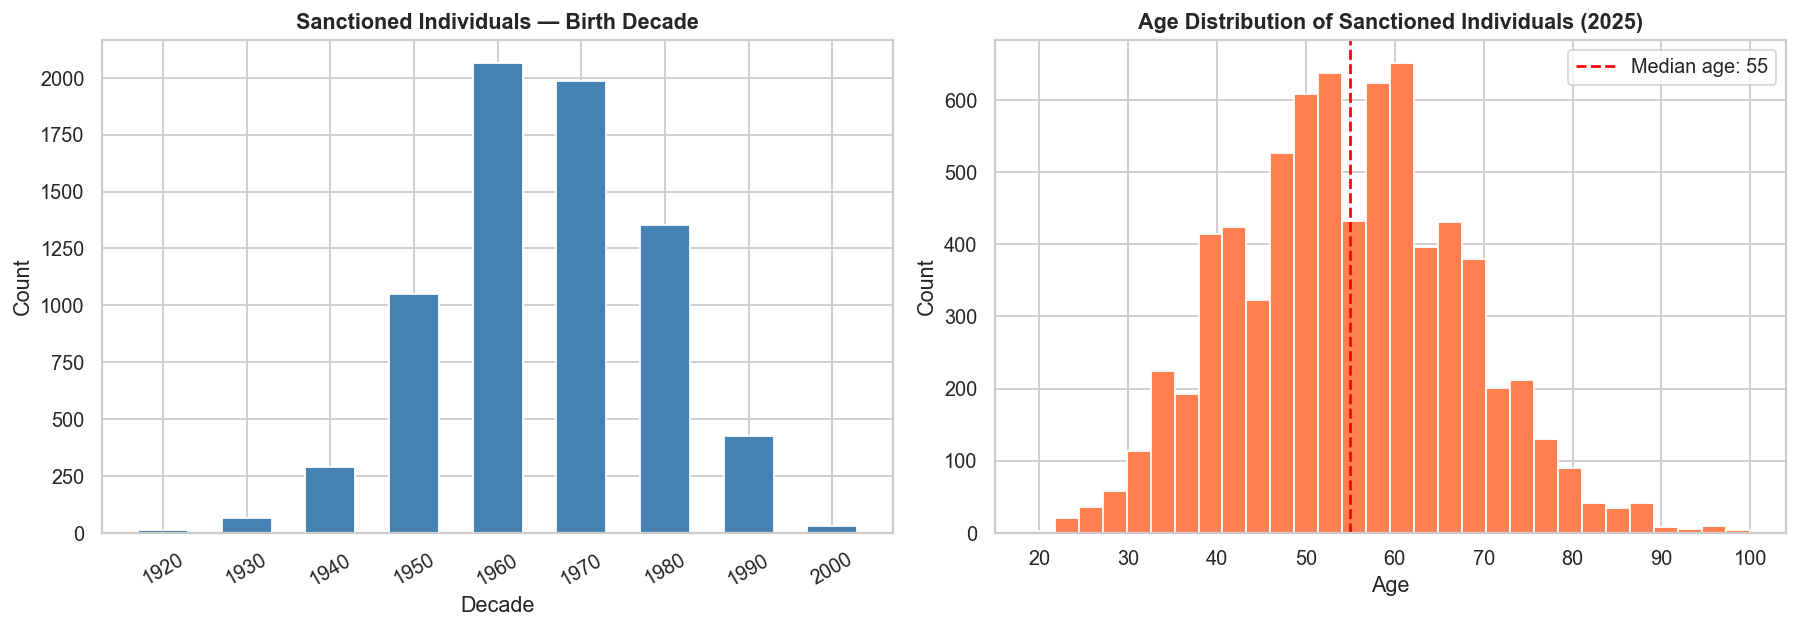

In [39]:
# --- 5.1 Birth Year Distribution of Sanctioned Individuals ---
# (Proxy for time dimension — OFAC doesn't include date_added in SDN CSV)
# We'll use DOB year as a temporal dimension

dob_df = df[df['dob_year'].notna() & (df['dob_year'] >= 1900) & (df['dob_year'] <= 2010)].copy()
birth_by_decade = dob_df.groupby((dob_df['dob_year'] // 10 * 10).astype(int)).size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Birth decade distribution
axes[0].bar(birth_by_decade.index.astype(str), birth_by_decade.values, color='steelblue', width=0.6)
axes[0].set_title('Sanctioned Individuals — Birth Decade', fontweight='bold')
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Age distribution (as of 2025)
dob_df['age'] = 2025 - dob_df['dob_year']
valid_ages = dob_df[(dob_df['age'] >= 15) & (dob_df['age'] <= 100)]['age']
axes[1].hist(valid_ages, bins=30, color='coral', edgecolor='white')
axes[1].axvline(valid_ages.median(), color='red', linestyle='--', label=f'Median age: {valid_ages.median():.0f}')
axes[1].set_title('Age Distribution of Sanctioned Individuals (2025)', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/temporal_analysis.png', dpi=150)
plt.show()

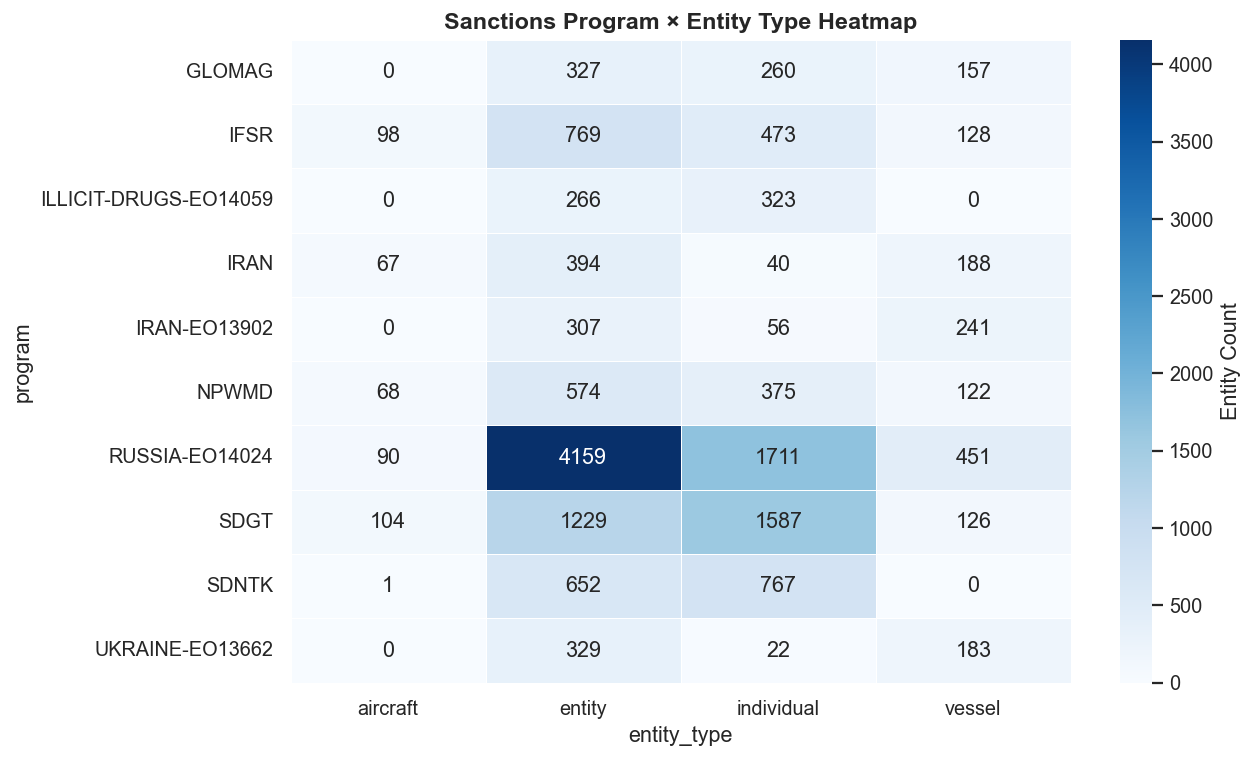

In [40]:
# --- 5.2 Program × Entity Type Heatmap (Temporal-style cross-analysis) ---
programs_exploded = df.explode('program_list')[['sdn_type','program_list']].dropna()
programs_exploded.columns = ['entity_type','program']

# Top programs and entity types
top_prog = programs_exploded['program'].value_counts().head(10).index
top_type = programs_exploded['entity_type'].value_counts().head(4).index

heatmap_df = programs_exploded[
    programs_exploded['program'].isin(top_prog) &
    programs_exploded['entity_type'].isin(top_type)
].pivot_table(index='program', columns='entity_type', aggfunc='size', fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Entity Count'})
plt.title('Sanctions Program × Entity Type Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/program_entity_heatmap.png', dpi=150)
plt.show()

## 6. Network Graph — Entity Relationship Mapping

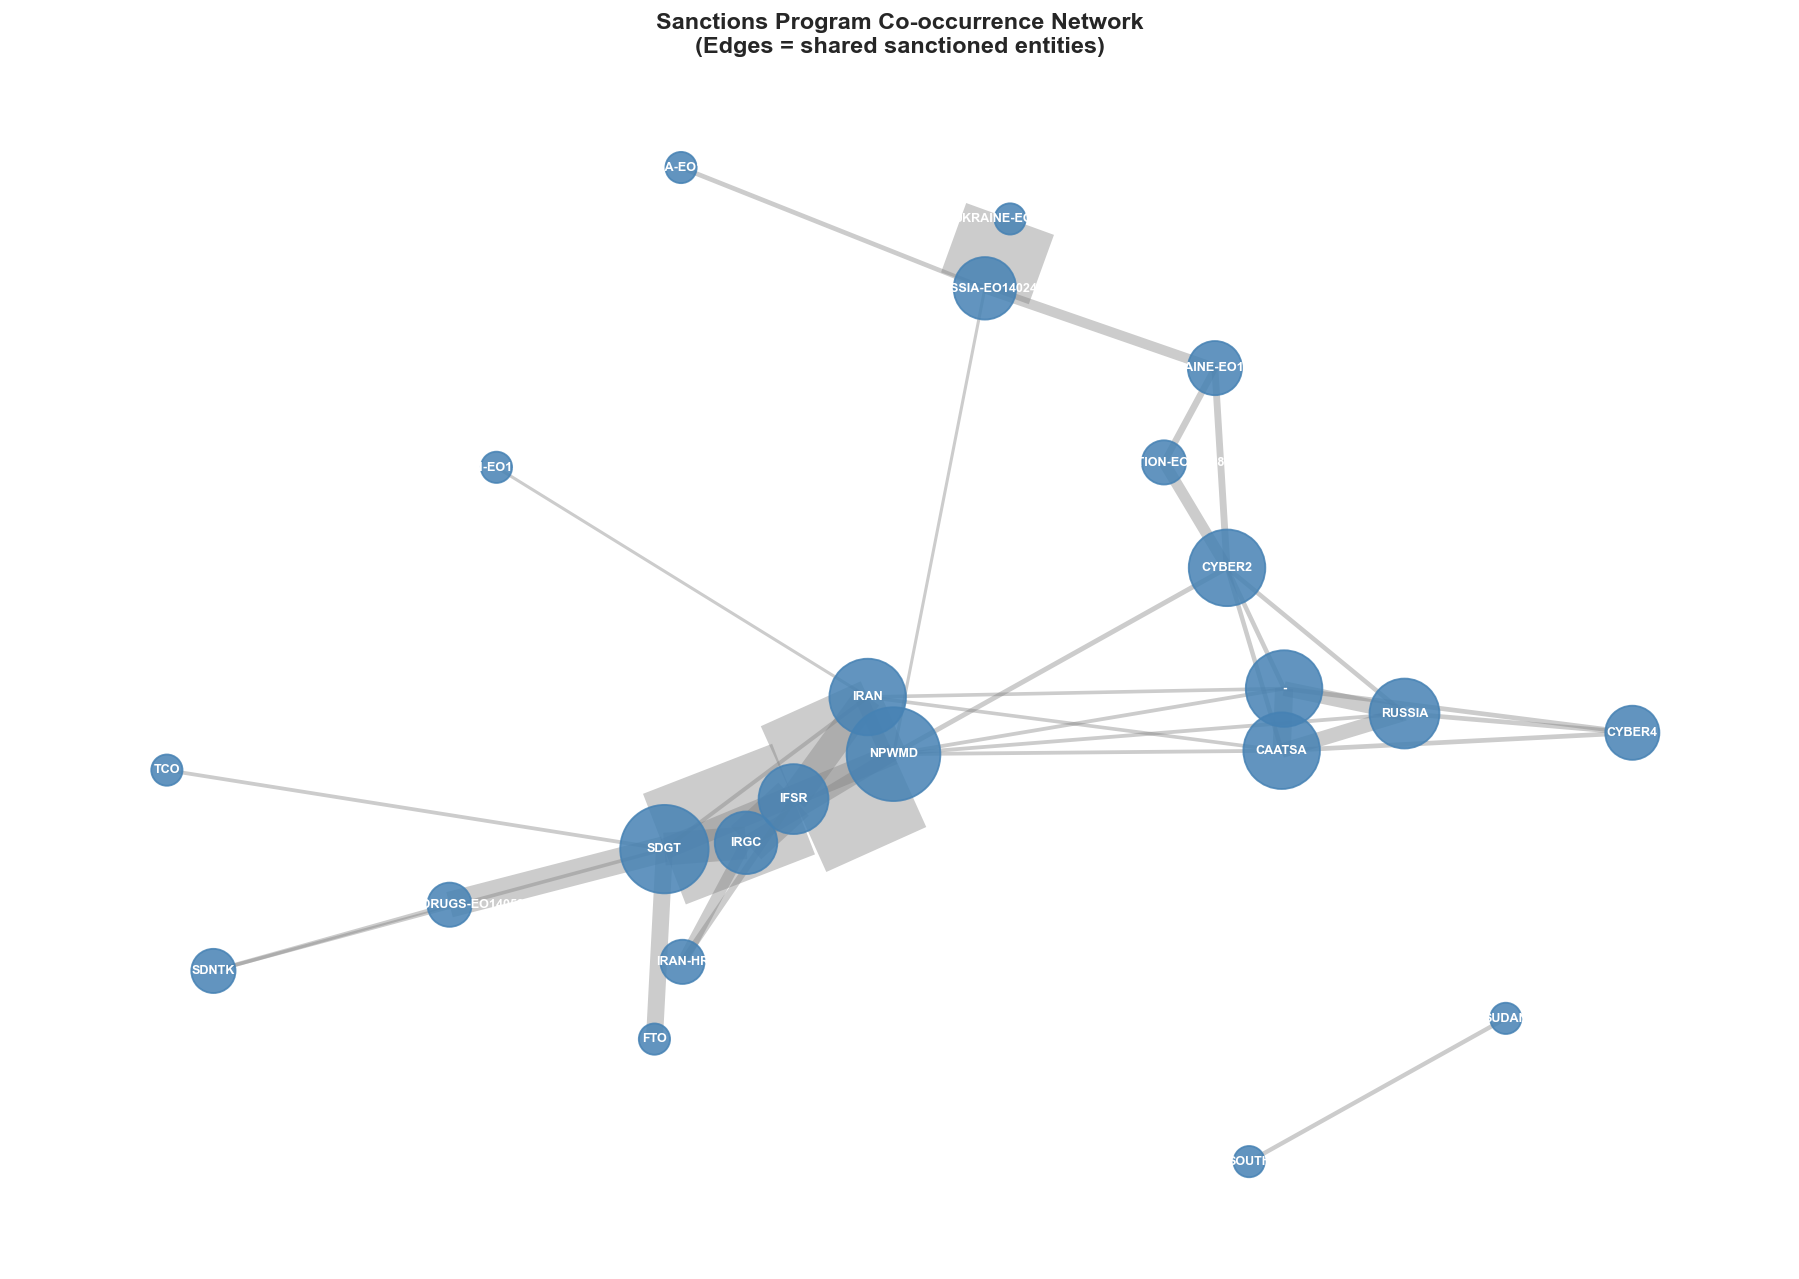

Nodes (programs): 23
Edges (co-occurrences): 40
Most connected program: ('NPWMD', 9)


In [41]:
# --- 6.1 Program Co-occurrence Network ---
# Entities sanctioned under multiple programs create links between those programs
# This reveals which sanctions regimes overlap / target the same actors

# Filter entities with 2+ programs
multi_prog = df[df['program_list'].apply(lambda x: isinstance(x, list) and len(x) >= 2)]['program_list']

# Build co-occurrence edge list
G_prog = nx.Graph()
edge_weights = Counter()

for prog_list in multi_prog:
    for pair in combinations(sorted(set(prog_list)), 2):
        edge_weights[pair] += 1

# Add top edges only (for readability)
top_edges = edge_weights.most_common(40)
for (p1, p2), weight in top_edges:
    G_prog.add_edge(p1, p2, weight=weight)

# Draw
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_prog, seed=42, k=2)
node_sizes = [G_prog.degree(n) * 300 for n in G_prog.nodes()]
edge_widths = [G_prog[u][v]['weight'] / 10 for u, v in G_prog.edges()]

nx.draw_networkx_nodes(G_prog, pos, node_size=node_sizes,
                       node_color='steelblue', alpha=0.85)
nx.draw_networkx_labels(G_prog, pos, font_size=7, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G_prog, pos, width=edge_widths, alpha=0.4, edge_color='gray')

plt.title('Sanctions Program Co-occurrence Network\n(Edges = shared sanctioned entities)', 
          fontweight='bold', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('../outputs/program_network.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Nodes (programs): {G_prog.number_of_nodes()}')
print(f'Edges (co-occurrences): {G_prog.number_of_edges()}')
print(f'Most connected program: {max(G_prog.degree, key=lambda x: x[1])}')

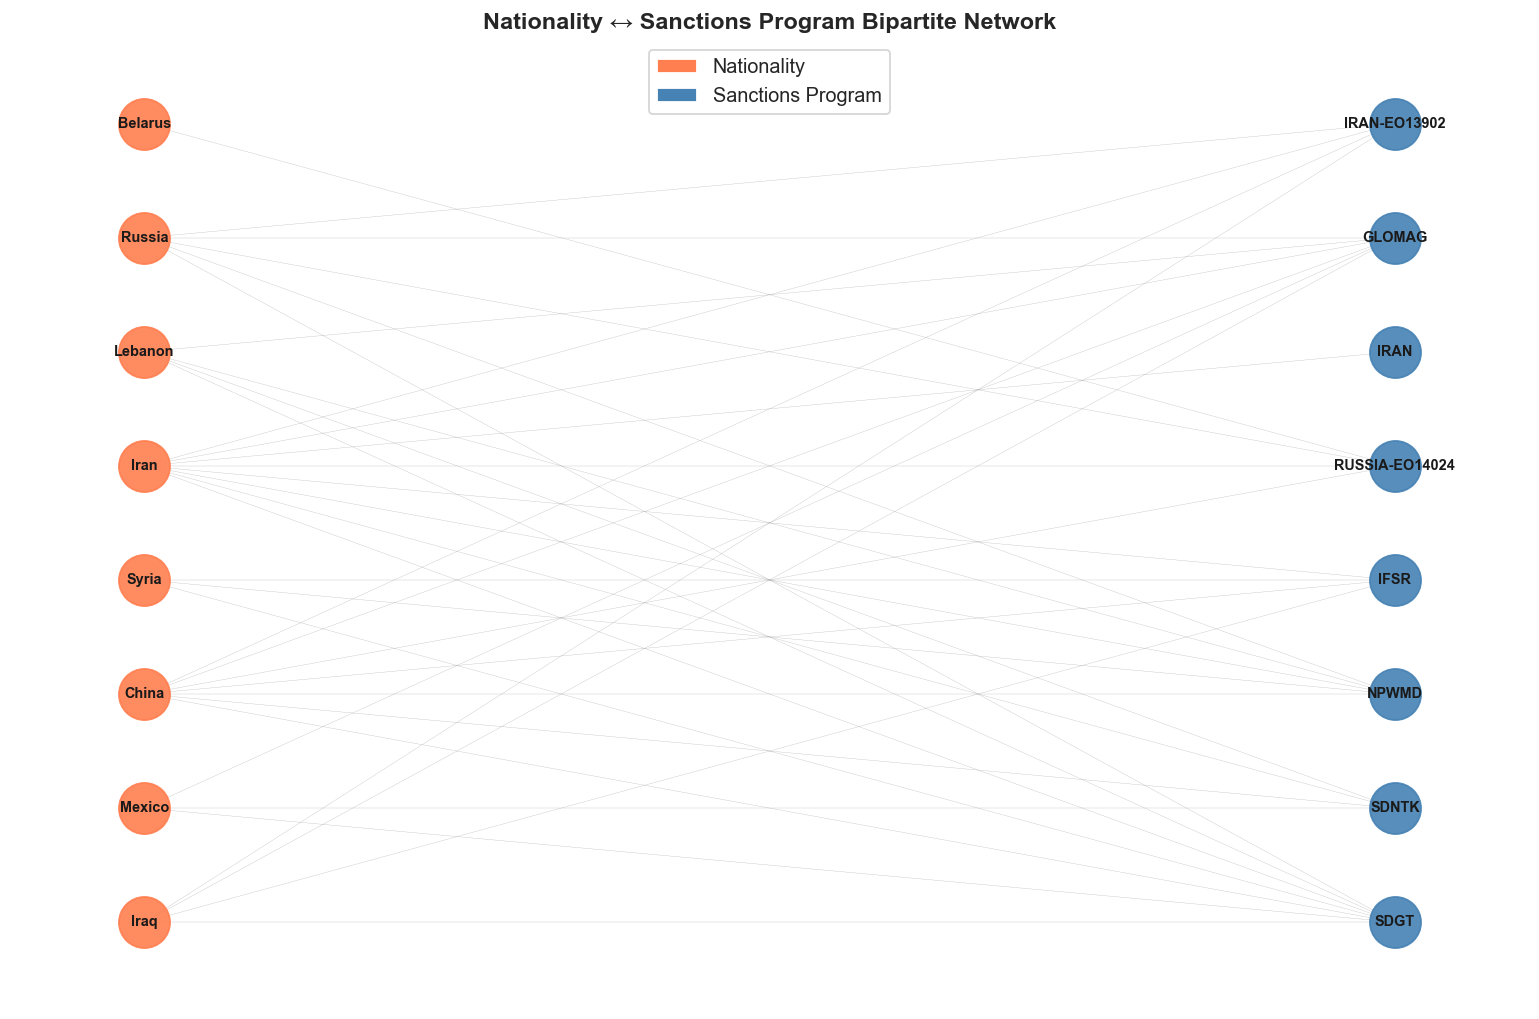

In [42]:
# --- 6.2 Nationality × Program Bipartite Network ---
# Link nationalities to programs — reveals geopolitical targeting patterns

nat_prog = df[df['nationality'].notna() & df['program_list'].apply(
    lambda x: isinstance(x, list) and len(x) > 0)][['nationality','program_list']]
nat_prog = nat_prog.explode('program_list')

# Filter to top nationalities and programs
top_nat_list  = df['nationality'].value_counts().head(8).index.tolist()
top_prog_list = all_programs.value_counts().head(8).index.tolist()

filtered = nat_prog[
    nat_prog['nationality'].isin(top_nat_list) &
    nat_prog['program_list'].isin(top_prog_list)
]

G_bip = nx.Graph()
nat_nodes  = list(filtered['nationality'].unique())
prog_nodes = list(filtered['program_list'].unique())

G_bip.add_nodes_from(nat_nodes,  bipartite=0)  # nationality
G_bip.add_nodes_from(prog_nodes, bipartite=1)  # program

for _, row in filtered.drop_duplicates().iterrows():
    if G_bip.has_edge(row['nationality'], row['program_list']):
        G_bip[row['nationality']][row['program_list']]['weight'] += 1
    else:
        G_bip.add_edge(row['nationality'], row['program_list'], weight=1)

# Draw bipartite
plt.figure(figsize=(12, 8))
pos_bip = {}
for i, n in enumerate(nat_nodes):  pos_bip[n]  = (0, i * 1.5)
for i, n in enumerate(prog_nodes): pos_bip[n]  = (3, i * 1.5)

nx.draw_networkx_nodes(G_bip, pos_bip, nodelist=nat_nodes,
                       node_color='coral', node_size=800, alpha=0.9)
nx.draw_networkx_nodes(G_bip, pos_bip, nodelist=prog_nodes,
                       node_color='steelblue', node_size=800, alpha=0.9)
nx.draw_networkx_labels(G_bip, pos_bip, font_size=8, font_weight='bold')
edge_w = [G_bip[u][v]['weight'] / 5 for u, v in G_bip.edges()]
nx.draw_networkx_edges(G_bip, pos_bip, width=edge_w, alpha=0.5, edge_color='gray')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='coral', label='Nationality'),
                   Patch(facecolor='steelblue', label='Sanctions Program')]
plt.legend(handles=legend_elements, loc='upper center')
plt.title('Nationality ↔ Sanctions Program Bipartite Network', fontweight='bold', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('../outputs/bipartite_network.png', dpi=150, bbox_inches='tight')
plt.show()